# 06 - Spatial Analysis

Analyses the distance between planning applications and their commenters, broken down by stance, housing type, and topic.

In [3]:
import sys
sys.path.append("../functions")

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from collections import Counter

import geopandas as gpd
from shapely.geometry import Polygon

from config import (
    RESULTS_DIR, FIGURES_DIR,
    FINETUNED_MODEL_DIR, TOPIC_RUN_DATE,
    STANCE_PALETTE,
)
from topic_processing import process_topics, build_topic_names

FIGURES_DIR.mkdir(parents=True, exist_ok=True)


## Load data

In [4]:
comment_df = pd.read_parquet(RESULTS_DIR / "comments.parquet")
pld_df     = pd.read_parquet(RESULTS_DIR / "pld.parquet")

# Load topic assignments from local model output (no DB needed)
raw_tp_df = pd.read_csv(FINETUNED_MODEL_DIR / "object_comments_with_topics.csv")
raw_tp_df = raw_tp_df.rename(columns={"topic": "topic_number", "topic_probs": "probability"})
# ast.literal_eval cannot parse 'nan'; replace with 0.0 before process_topics parses the strings.
# nan probabilities only appear on noise topic -1 which is filtered out anyway.
raw_tp_df["probability"] = raw_tp_df["probability"].apply(
    lambda s: s.replace("nan", "0.0") if isinstance(s, str) else s
)
tp_df = process_topics(raw_tp_df)  # parses string lists, filters bad topics, collapses duplicates

raw_topic_names = pd.read_csv(FINETUNED_MODEL_DIR / "object_topics.csv")
topic_names     = build_topic_names(raw_topic_names)
topic_name_lookup = topic_names.set_index("Topic")["topic_group"].to_dict()

# Merge comments with topics
df = pd.merge(comment_df,
              tp_df[["comment_id", "topic_number", "probability"]],
              on="comment_id", how="left")

# Merge housing type from planning data
pld_df["lpa_app_no_borough"] = pld_df["lpa_app_no"] + "_" + pld_df["borough"]
df["lpa_app_no_borough"]     = df["application_id"] + "_" + df["council"]
df = pd.merge(df, pld_df[["lpa_app_no_borough", "housing_type",
                            "total_no_proposed_residential_units"]],
              on="lpa_app_no_borough", how="left")
print(f"{len(df):,} comments loaded")


30,424 comments loaded


## Build application centroid GeoDataFrame

In [5]:
def _make_polygon(coords):
    try:
        ring = np.vstack(coords[0])  # coords[0] is the outer ring: array of [lon, lat]
        return Polygon(ring)
    except Exception:
        return None

app_geo = pld_df.dropna(subset=["wgs84_polygon.coordinates"]).copy()
app_geo["geometry"] = app_geo["wgs84_polygon.coordinates"].apply(_make_polygon)
app_gdf = gpd.GeoDataFrame(app_geo, geometry="geometry", crs="EPSG:4326")

# Project to British National Grid for accurate centroid, then back to WGS84
centroids_wgs = app_gdf.to_crs("EPSG:27700").geometry.centroid.to_crs("EPSG:4326")
app_gdf["centroid_lat"] = centroids_wgs.y
app_gdf["centroid_lon"] = centroids_wgs.x
print(f"Applications with centroids: {app_gdf['centroid_lat'].notna().sum():,}")


Applications with centroids: 25,477


## Calculate commenter–application distance (Haversine)

In [6]:
def haversine_vec(lat1, lon1, lat2, lon2):
    """Vectorised haversine distance in km; returns NaN where inputs are NaN."""
    R = 6371.0
    lat1, lon1, lat2, lon2 = (
        np.radians(lat1), np.radians(lon1),
        np.radians(lat2), np.radians(lon2),
    )
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

# Build centroid lookup keyed on lpa_app_no (one row per application)
centroid_lookup = (
    app_gdf[["lpa_app_no", "borough", "centroid_lat", "centroid_lon"]]
    .dropna(subset=["centroid_lat", "centroid_lon"])
    .drop_duplicates("lpa_app_no")
)

df = df.merge(
    centroid_lookup.rename(columns={"centroid_lat": "app_lat", "centroid_lon": "app_lon"}),
    left_on=["application_id", "council"],
    right_on=["lpa_app_no", "borough"],
    how="left",
)

df["distance_km"] = haversine_vec(
    df["lat"].to_numpy(), df["lon"].to_numpy(),
    df["app_lat"].to_numpy(), df["app_lon"].to_numpy(),
)

print(df["distance_km"].describe())


count    18270.000000
mean         1.417088
std          3.260108
min          0.000087
25%          0.076757
50%          0.261594
75%          0.863824
max         34.469805
Name: distance_km, dtype: float64


## Distance distributions

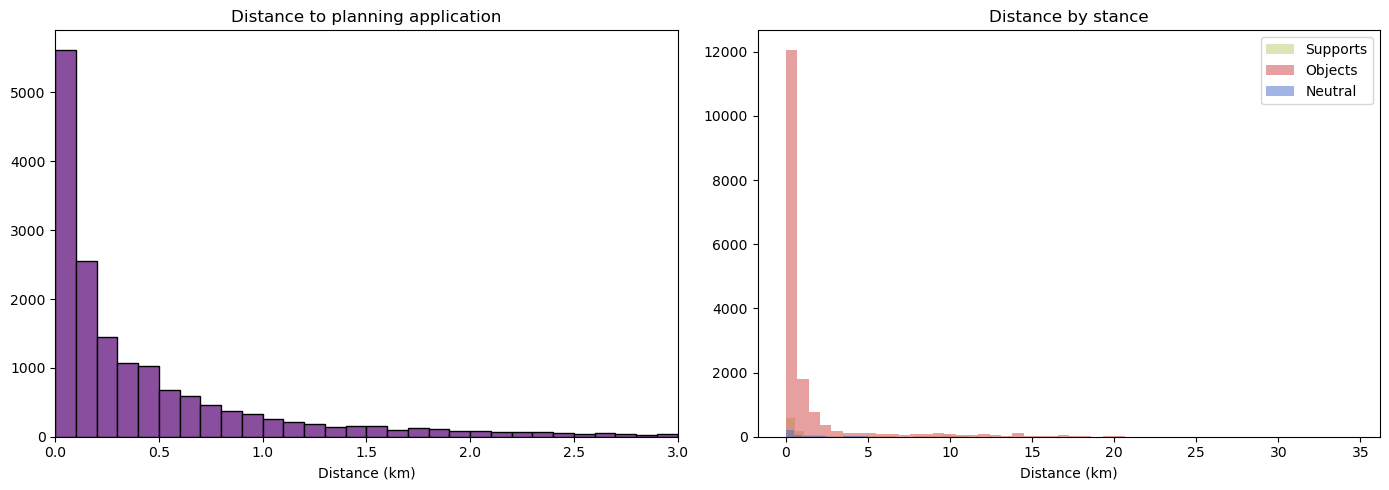

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall histogram
bin_width = 0.1
max_d = 20
bins = np.arange(0, max_d + bin_width, bin_width)
axes[0].hist(df["distance_km"].dropna(), bins=bins, color="#894e9e", edgecolor="black")
axes[0].set_xlim(0, 3)
axes[0].set_xlabel("Distance (km)")
axes[0].set_title("Distance to planning application")

# By stance
for stance, color in STANCE_PALETTE.items():
    sub = df[df["stance"] == stance]["distance_km"].dropna()
    axes[1].hist(sub, bins=50, alpha=0.5, label=stance, color=color)
axes[1].set_xlabel("Distance (km)")
axes[1].set_title("Distance by stance")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "distance_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## Distance by topic (boxplot)

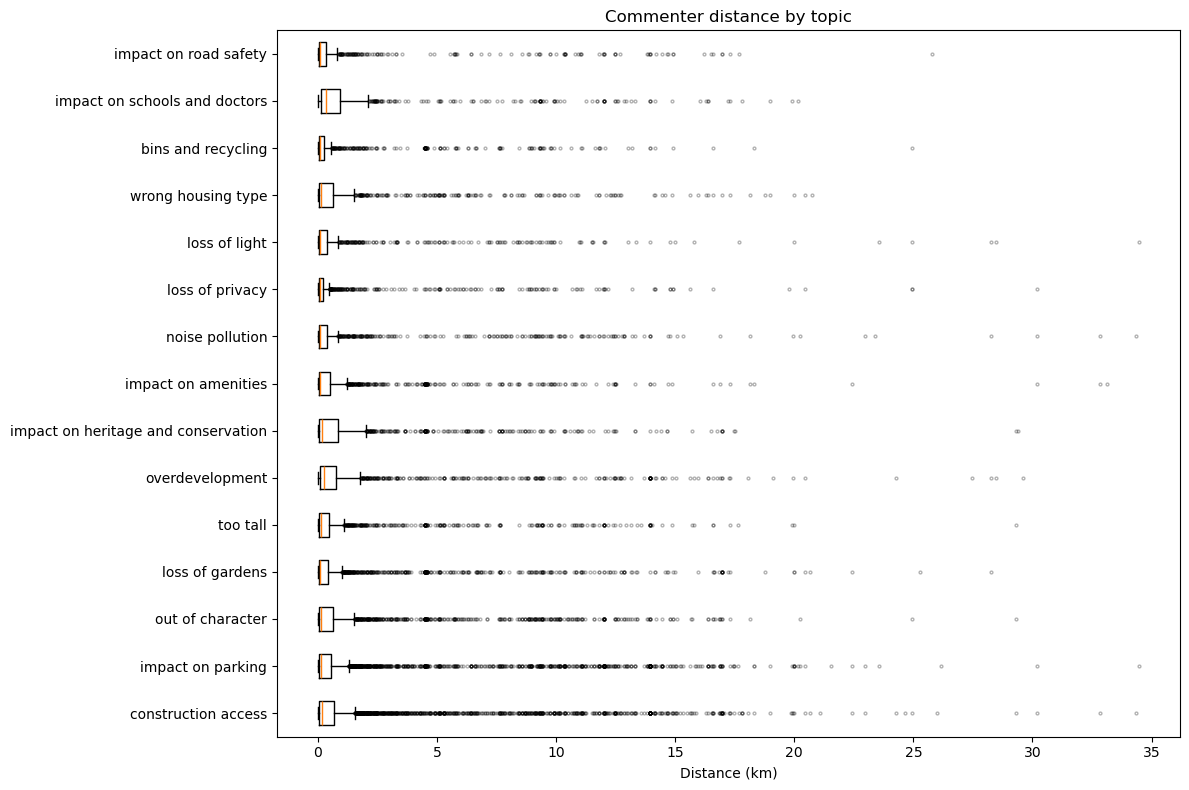

In [8]:
topic_counts = Counter(df["topic_number"].explode().dropna())
top_topics = [t for t, _ in topic_counts.most_common(15)]

data_to_plot = []
labels = []
for topic in top_topics:
    distances = df[df["topic_number"].apply(
        lambda x: topic in x if isinstance(x, list) else False
    )]["distance_km"].dropna()
    if len(distances) > 0:
        data_to_plot.append(distances)
        labels.append(topic_name_lookup.get(topic, f"Topic {topic}"))

fig, ax = plt.subplots(figsize=(12, 8))
ax.boxplot(data_to_plot, vert=False, flierprops=dict(marker="o", markersize=2, alpha=0.3))
ax.set_yticks(range(1, len(labels) + 1))
ax.set_yticklabels(labels)
ax.set_xlabel("Distance (km)")
ax.set_title("Commenter distance by topic")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "distance_by_topic.png", dpi=150, bbox_inches="tight")
plt.show()

## Distance by housing type

/var/folders/4n/x6w1yfcx01qbymrsfpz4ybq00000gn/T/ipykernel_74729/2160788192.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(ht_data, labels=ht_labels, vert=True,


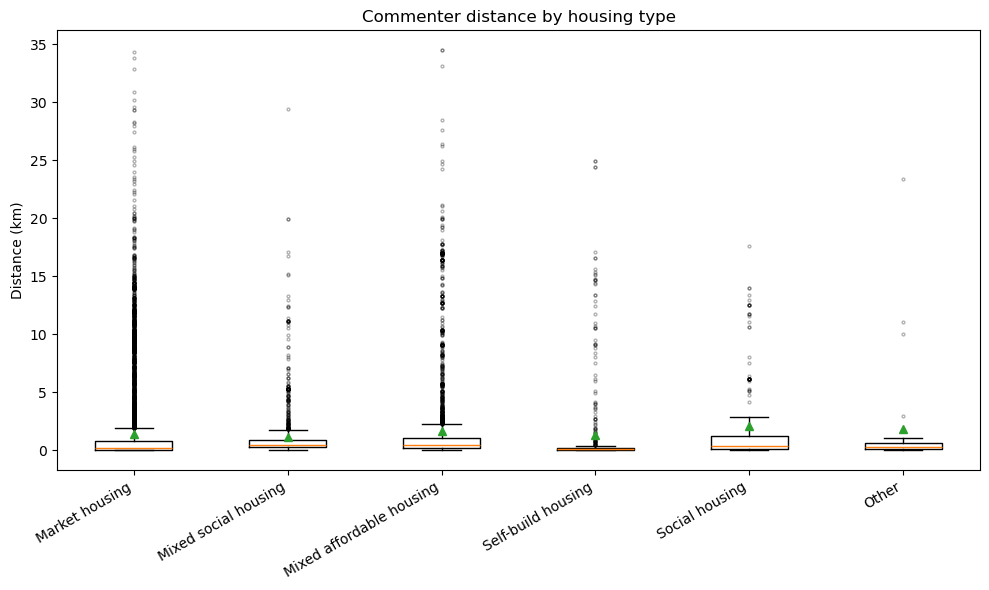

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
ht_data   = []
ht_labels = []
for ht in df["housing_type"].dropna().unique():
    d = df[df["housing_type"] == ht]["distance_km"].dropna()
    if len(d):
        ht_data.append(d)
        ht_labels.append(ht)

ax.boxplot(ht_data, labels=ht_labels, vert=True,
           flierprops=dict(marker="o", markersize=2, alpha=0.3), showmeans=True)
ax.set_ylabel("Distance (km)")
ax.set_title("Commenter distance by housing type")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "distance_by_housing_type.png", dpi=150, bbox_inches="tight")
plt.show()